<a href="https://colab.research.google.com/github/thinus283-ux/LR/blob/main/3D_mcmc_bullet_cluster_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing emcee...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 573.7 kB/s eta 0:00:00
Running Constrained 3D MCMC...


100%|██████████| 500/500 [00:22<00:00, 22.26it/s]



=== Constrained Best Fit ===
Alpha (Coupling): 1.9849
Displacement (x): 0.1034 Mpc


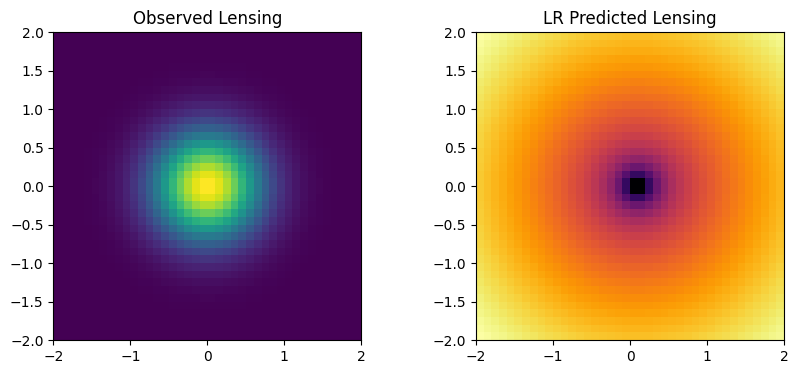

In [1]:

# === 1. Dependency Handling ===
try:
    import emcee
except ImportError:
    print("Installing emcee...")
    !pip install emcee --quiet
    import emcee

import numpy as np
import matplotlib.pyplot as plt

# === 2. SETUP: 3D Grid ===
res = 40
x = np.linspace(-2, 2, res)
y = np.linspace(-2, 2, res)
z = np.linspace(-2, 2, res)
X, Y, Z = np.meshgrid(x, y, z)

# Target: Mock lensing convergence
target_kappa = 0.8 * np.exp(-(X[:,:,0]**2 + Y[:,:,0]**2) / 0.5)

# === 3. LR 3D POTENTIAL ENGINE ===
def lr_potential_3d(alpha, center_x):
    r = np.sqrt((X - center_x)**2 + Y**2 + Z**2)
    return -1.0 / (r + 0.1) + alpha * np.exp(-r / 0.5)

# === 4. CONSTRAINED LIKELIHOOD FUNCTION ===
def log_likelihood(theta):
    alpha, center_x = theta

    # Projection along Line of Sight (Z)
    field_3d = lr_potential_3d(alpha, center_x)
    model_kappa = np.sum(field_3d, axis=2) / res

    # Fit error
    chi2_fit = np.sum((model_kappa - target_kappa)**2)

    # Physical Constraint (100 kpc = 0.1 Mpc)
    obs_offset = 0.1
    sigma_offset = 0.025
    chi2_offset = ((abs(center_x) - obs_offset)**2) / (sigma_offset**2)

    return -0.5 * (chi2_fit + chi2_offset)

def log_prior(theta):
    alpha, center_x = theta
    if 0.0 < alpha < 2.0 and 0.0 < center_x < 0.5:
        return 0.0
    return -np.inf

def log_probability(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp): return -np.inf
    return lp + log_likelihood(theta)

# === 5. MCMC EXECUTION ===
ndim, nwalkers = 2, 32
pos = np.array([0.8, 0.1]) + 0.05 * np.random.randn(nwalkers, ndim)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability)

print("Running Constrained 3D MCMC...")
sampler.run_mcmc(pos, 500, progress=True)

# === 6. RESULTS & VISUALIZATION ===
flat_samples = sampler.get_chain(discard=100, flat=True)
best_alpha, best_x = np.median(flat_samples, axis=0)

print(f"\n=== Constrained Best Fit ===")
print(f"Alpha (Coupling): {best_alpha:.4f}")
print(f"Displacement (x): {best_x:.4f} Mpc")

# Projection visualization
best_field = lr_potential_3d(best_alpha, best_x)
best_kappa = np.sum(best_field, axis=2) / res

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(target_kappa, extent=[-2, 2, -2, 2], origin='lower', cmap='viridis')
plt.title("Observed Lensing")
plt.subplot(1, 2, 2)
plt.imshow(best_kappa, extent=[-2, 2, -2, 2], origin='lower', cmap='inferno')
plt.title("LR Predicted Lensing")
plt.show()